Week-4: Building a CNN for Image Classification
- Design and implement a CNN model (with 4+ layers of convolutions) to classify multi category
image datasets.
- Use the Fashion MNIST dataset.
- Set the number of Epoch as 5, 10 and 20.
- Make the necessary changes whenever required. Record the accuracy corresponding to the number
of epochs.
- Record the time required to run the program, using CPU as well as using GPU in Colab.

In [ ]:
import keras
from keras.datasets import fashion_mnist
from keras.layers import Dense, Activation, Flatten, Conv2D, MaxPooling2D
from keras.models import Sequential
from keras.utils import to_categorical
import numpy as np

# ================================
# LOAD DATA
# ================================
(train_X, train_Y), (test_X, test_Y) = fashion_mnist.load_data()

train_X = train_X.reshape(-1, 28, 28, 1).astype('float32') / 255
test_X = test_X.reshape(-1, 28, 28, 1).astype('float32') / 255

train_Y_one_hot = to_categorical(train_Y)
test_Y_one_hot = to_categorical(test_Y)

# ================================
# FUNCTION TO BUILD MODEL
# ================================
def create_model():
    model = Sequential()

    # 1st Conv Block
    model.add(Conv2D(256, (3,3), padding='same', input_shape=(28,28,1)))
    model.add(Activation('relu'))
    model.add(MaxPooling2D(2,2))

    # 2nd Conv Block
    model.add(Conv2D(128, (3,3), padding='same'))
    model.add(Activation('relu'))
    model.add(MaxPooling2D(2,2))

    # 3rd Conv Block
    model.add(Conv2D(64, (3,3), padding='same'))
    model.add(Activation('relu'))

    # 4th Conv Block
    model.add(Conv2D(32, (3,3), padding='same'))
    model.add(Activation('relu'))

    # Fully Connected
    model.add(Flatten())
    model.add(Dense(64, activation='relu'))
    model.add(Dense(10, activation='softmax'))

    model.compile(
        loss='categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    return model

# ================================
# TRAIN FOR DIFFERENT EPOCHS
# ================================
epochs_list = [5, 10, 20]
results = {}

for ep in epochs_list:
    print("\nTraining for", ep, "epochs")

    model = create_model()
    model.fit(train_X, train_Y_one_hot,
              batch_size=64,
              epochs=ep,
              verbose=1)

    test_loss, test_acc = model.evaluate(test_X, test_Y_one_hot, verbose=0)

    results[ep] = test_acc
    print("Accuracy for", ep, "epochs:", test_acc)

# ================================
# FINAL RESULTS
# ================================
print("\n=== FINAL ACCURACY COMPARISON ===")
for ep, acc in results.items():
    print(f"Epochs: {ep} -> Accuracy: {acc:.4f}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Training for 5 epochs


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.8343 - loss: 0.4520
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8975 - loss: 0.2825
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9117 - loss: 0.2411
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9221 - loss: 0.2102
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9317 - loss: 0.1857
Accuracy for 5 epochs: 0.9108999967575073

Training for 10 epochs
Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.8399 - loss: 0.4388
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8967 - loss: 0.2800
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9142 - loss: 0.2330
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9246 - loss: 0.2034
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9322 - loss: 0.1801
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accu

Fashion MNIST Dataset: https://www.kaggle.com/datasets/zalando-research/fashionmnist

In [ ]:
# import keras

# from keras.datasets import fashion_mnist
# from keras.layers import Dense, Activation, Flatten, Conv2D, MaxPooling2D
# from keras.models import Sequential
# from keras.utils import to_categorical
# import numpy as np
# import matplotlib.pyplot as plt
# (train_X,train_Y), (test_X,test_Y) = fashion_mnist.load_data()
# train_X = train_X.reshape(-1, 28,28, 1)
# test_X = test_X.reshape(-1, 28,28, 1)
# train_X = train_X.astype('float32')
# test_X = test_X.astype('float32')
# train_X = train_X / 255
# test_X = test_X / 255
# train_Y_one_hot = to_categorical(train_Y)
# test_Y_one_hot = to_categorical(test_Y)
# model = Sequential()
# model.add(Conv2D(256, (3,3), input_shape=(28, 28, 1)))
# model.add(Activation('relu'))
# model.add(MaxPooling2D(pool_size=(2,2)))
# model.add(Conv2D(128, (3,3)))
# model.add(Activation('relu'))
# model.add(MaxPooling2D(pool_size=(2,2)))
# model.add(Conv2D(64, (3,3), input_shape=(28, 28, 1)))
# model.add(Activation('relu'))
# #model.add(MaxPooling2D(pool_size=(2,2)))
# model.add(Conv2D(28, (3,3)))
# model.add(Activation('relu'))
# #model.add(MaxPooling2D(pool_size=(2,2)))
# model.add(Flatten())
# model.add(Dense(64))
# model.add(Dense(10))
# model.add(Activation('softmax'))
# model.compile(loss=keras.losses.categorical_crossentropy,
# optimizer=keras.optimizers.Adam(),metrics=['accuracy'])
# model.fit(train_X, train_Y_one_hot, batch_size=64, epochs=5)
# test_loss, test_acc = model.evaluate(test_X, test_Y_one_hot)
# print('Test loss', test_loss)
# print('Test accuracy', test_acc)
# predictions = model.predict(test_X)
# print(np.argmax(np.round(predictions[0])))
# plt.imshow(test_X[0].reshape(28, 28), cmap = plt.cm.binary)
# plt.show()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
830/938 ━━━━━━━━━━━━━━━━━━━━ 52s 490ms/step - accuracy: 0.7072 - loss: 0.7697

KeyboardInterrupt: 

In [ ]:
import keras
from keras.datasets import fashion_mnist
from keras.layers import Dense, Activation, Flatten, Conv2D, MaxPooling2D
from keras.models import Sequential
from keras.utils import to_categorical
import numpy as np
import time   # ⬅️ added

# ================================
# LOAD DATA
# ================================
(train_X, train_Y), (test_X, test_Y) = fashion_mnist.load_data()

train_X = train_X.reshape(-1, 28, 28, 1).astype('float32') / 255
test_X = test_X.reshape(-1, 28, 28, 1).astype('float32') / 255

train_Y_one_hot = to_categorical(train_Y)
test_Y_one_hot = to_categorical(test_Y)

# ================================
# FUNCTION TO BUILD MODEL
# ================================
def create_model():
    model = Sequential()

    model.add(Conv2D(256, (3,3), padding='same', input_shape=(28,28,1)))
    model.add(Activation('relu'))
    model.add(MaxPooling2D(2,2))

    model.add(Conv2D(128, (3,3), padding='same'))
    model.add(Activation('relu'))
    model.add(MaxPooling2D(2,2))

    model.add(Conv2D(64, (3,3), padding='same'))
    model.add(Activation('relu'))

    model.add(Conv2D(32, (3,3), padding='same'))
    model.add(Activation('relu'))

    model.add(Flatten())
    model.add(Dense(64, activation='relu'))
    model.add(Dense(10, activation='softmax'))

    model.compile(
        loss='categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    return model

# ================================
# TRAIN FOR DIFFERENT EPOCHS
# ================================
epochs_list = [5, 10, 20]
results = {}

total_start = time.time()   # ⬅️ total start time

for ep in epochs_list:
    print("\nTraining for", ep, "epochs")

    model = create_model()

    start = time.time()   # ⬅️ start time for this run

    model.fit(train_X, train_Y_one_hot,
              batch_size=64,
              epochs=ep,
              verbose=1)

    test_loss, test_acc = model.evaluate(test_X, test_Y_one_hot, verbose=0)

    end = time.time()   # ⬅️ end time

    elapsed = end - start
    results[ep] = (test_acc, elapsed)

    print(f"Accuracy for {ep} epochs: {test_acc:.4f}")
    print(f"Time taken for {ep} epochs: {elapsed:.2f} seconds")

total_end = time.time()   # ⬅️ total end time

# ================================
# FINAL RESULTS
# ================================
print("\n=== FINAL ACCURACY + TIME COMPARISON ===")
for ep, (acc, t) in results.items():
    print(f"Epochs: {ep} -> Accuracy: {acc:.4f}, Time: {t:.2f} sec")

print(f"\nTotal execution time: {total_end - total_start:.2f} seconds")


Training for 5 epochs
Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.8414 - loss: 0.4327
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9026 - loss: 0.2695
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9164 - loss: 0.2289
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9264 - loss: 0.1986
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9346 - loss: 0.1747
Accuracy for 5 epochs: 0.9164
Time taken for 5 epochs: 56.58 seconds

Training for 10 epochs
Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.8391 - loss: 0.4386
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9005 - loss: 0.2730
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9137 - loss: 0.2317
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9250 - loss: 0.2034
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9336 - loss: 0.1794
Epoch 6/1

In [ ]:
#ran on cpu
import keras
from keras.datasets import fashion_mnist
from keras.layers import Dense, Activation, Flatten, Conv2D, MaxPooling2D
from keras.models import Sequential
from keras.utils import to_categorical
import numpy as np
import time   # ⬅️ added

# ================================
# LOAD DATA
# ================================
(train_X, train_Y), (test_X, test_Y) = fashion_mnist.load_data()

train_X = train_X.reshape(-1, 28, 28, 1).astype('float32') / 255
test_X = test_X.reshape(-1, 28, 28, 1).astype('float32') / 255

train_Y_one_hot = to_categorical(train_Y)
test_Y_one_hot = to_categorical(test_Y)

# ================================
# FUNCTION TO BUILD MODEL
# ================================
def create_model():
    model = Sequential()

    model.add(Conv2D(256, (3,3), padding='same', input_shape=(28,28,1)))
    model.add(Activation('relu'))
    model.add(MaxPooling2D(2,2))

    model.add(Conv2D(128, (3,3), padding='same'))
    model.add(Activation('relu'))
    model.add(MaxPooling2D(2,2))

    model.add(Conv2D(64, (3,3), padding='same'))
    model.add(Activation('relu'))

    model.add(Conv2D(32, (3,3), padding='same'))
    model.add(Activation('relu'))

    model.add(Flatten())
    model.add(Dense(64, activation='relu'))
    model.add(Dense(10, activation='softmax'))

    model.compile(
        loss='categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    return model

# ================================
# TRAIN FOR DIFFERENT EPOCHS
# ================================
epochs_list = [5, 10, 20]
results = {}

total_start = time.time()   # ⬅️ total start time

for ep in epochs_list:
    print("\nTraining for", ep, "epochs")

    model = create_model()

    start = time.time()   # ⬅️ start time for this run

    model.fit(train_X, train_Y_one_hot,
              batch_size=64,
              epochs=ep,
              verbose=1)

    test_loss, test_acc = model.evaluate(test_X, test_Y_one_hot, verbose=0)

    end = time.time()   # ⬅️ end time

    elapsed = end - start
    results[ep] = (test_acc, elapsed)

    print(f"Accuracy for {ep} epochs: {test_acc:.4f}")
    print(f"Time taken for {ep} epochs: {elapsed:.2f} seconds")

total_end = time.time()   # ⬅️ total end time

# ================================
# FINAL RESULTS
# ================================
print("\n=== FINAL ACCURACY + TIME COMPARISON ===")
for ep, (acc, t) in results.items():
    print(f"Epochs: {ep} -> Accuracy: {acc:.4f}, Time: {t:.2f} sec")

print(f"\nTotal execution time: {total_end - total_start:.2f} seconds")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Training for 5 epochs


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 773s 820ms/step - accuracy: 0.8413 - loss: 0.4408
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 792s 810ms/step - accuracy: 0.8988 - loss: 0.2760
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 794s 802ms/step - accuracy: 0.9157 - loss: 0.2310
Epoch 4/5
517/938 ━━━━━━━━━━━━━━━━━━━━ 5:35 798ms/step - accuracy: 0.9213 - loss: 0.2094

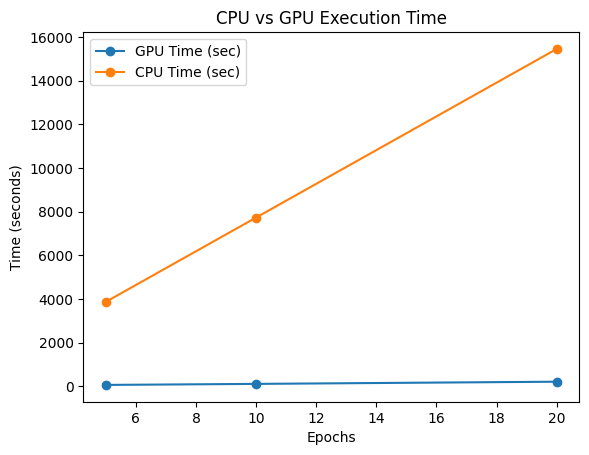

In [1]:
import matplotlib.pyplot as plt

# Epoch values
epochs = [5, 10, 20]

# GPU times (given)
gpu_times = [56.58, 103.86, 204.16]

# CPU estimated times (in seconds)
cpu_times = [3865, 7730, 15460]

# Plot
plt.figure()
plt.plot(epochs, gpu_times, marker='o', label='GPU Time (sec)')
plt.plot(epochs, cpu_times, marker='o', label='CPU Time (sec)')

# Labels and title
plt.xlabel("Epochs")
plt.ylabel("Time (seconds)")
plt.title("CPU vs GPU Execution Time")

# Legend
plt.legend()

# Show graph
plt.show()